Imports

In [5]:
from pathlib import Path
import pickle
import random
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

Configure Device

In [10]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


Load Shared vocabulary and Sequence Data

In [11]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Could not find the project data directory.")
        
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
SHARED_DIR = DATA_DIR / "shared"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Shared data:", SHARED_DIR)



Project root: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels
Shared data: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels\data\shared


In [12]:
with open(SHARED_DIR / "vocabulary.pkl", "rb") as file:
    vocab = pickle.load(file)

word_to_idx = vocab["word_to_idx"]
MAX_LENGTH = vocab["MAX_LENGTH"]

sequence_data = np.load(SHARED_DIR / "sequence_data.npz")

train_padded = sequence_data["train_padded"]
val_padded = sequence_data["val_padded"]
test_padded = sequence_data["test_padded"]

train_lengths = sequence_data["train_lengths"]
val_lengths = sequence_data["val_lengths"]
test_lengths = sequence_data["test_lengths"]

y_train = sequence_data["y_train"]
y_val = sequence_data["y_val"]
y_test = sequence_data["y_test"]

print(f"Vocabulary size: {len(word_to_idx):,}")
print(f"Maximum sequence length: {MAX_LENGTH}")
print("Training sequences:", train_padded.shape)
print("Validation sequences:", val_padded.shape)
print("Testing sequences:", test_padded.shape)

Vocabulary size: 60,725
Maximum sequence length: 321
Training sequences: (19923, 321)
Validation sequences: (4981, 321)
Testing sequences: (24801, 321)


PyTorch Dataset and DataLoaders

In [13]:
class ReviewDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.sequences[index],
            self.lengths[index],
            self.labels[index]
        )

In [14]:
train_dataset = ReviewDataset(
    train_padded,
    train_lengths,
    y_train
)

val_dataset = ReviewDataset(
    val_padded,
    val_lengths,
    y_val
)

test_dataset = ReviewDataset(
    test_padded,
    test_lengths,
    y_test
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 19923
Validation samples: 4981
Testing samples: 24801


In [15]:
BATCH_SIZE = 32

data_generator = torch.Generator()
data_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda",
    generator=data_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 623
Validation batches: 156
Testing batches: 776


In [16]:
sequences_batch, lengths_batch, labels_batch = next(iter(train_loader))

print("Sequences shape:", sequences_batch.shape)
print("Lengths shape:", lengths_batch.shape)
print("Labels shape:", labels_batch.shape)

print("\nFirst five lengths:", lengths_batch[:5])
print("First five labels:", labels_batch[:5])

Sequences shape: torch.Size([32, 321])
Lengths shape: torch.Size([32])
Labels shape: torch.Size([32])

First five lengths: tensor([ 22, 226,  64,  23, 321])
First five labels: tensor([1., 1., 0., 0., 1.])


## Word2Vec

In [18]:
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec

train_df = pd.read_csv(DATA_DIR / "train_processed.csv")

word2vec_train_df, _ = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)

train_tokens = (
    word2vec_train_df["processed_text"]
    .fillna("")
    .str.split()
    .tolist()
)

print("Word2Vec training reviews:", len(train_tokens))
print("First review tokens:", train_tokens[0][:10])

Word2Vec training reviews: 19923
First review tokens: ['saddens', 'rate', 'movie', 'lot', 'favorite', 'actor', 'location', 'genre', 'e', 'douglas']


In [19]:
WORD2VEC_DIM = 100
WORD2VEC_MODEL_PATH = MODELS_DIR / "word2vec_imdb.model"
WORD2VEC_MATRIX_PATH = MODELS_DIR / "word2vec_embedding_matrix.npy"

if WORD2VEC_MATRIX_PATH.exists():
    word2vec_embedding_matrix = np.load(WORD2VEC_MATRIX_PATH)
    print("Loaded existing Word2Vec embedding matrix.")

else:
    print("Training Word2Vec...")
    start_time = time.time()

    word2vec_model = Word2Vec(
        sentences=train_tokens,
        vector_size=WORD2VEC_DIM,
        window=5,
        min_count=2,
        workers=1,
        sg=1,
        epochs=10,
        seed=SEED
    )

    word2vec_model.save(str(WORD2VEC_MODEL_PATH))

    elapsed_time = time.time() - start_time

    print(f"Training completed in {elapsed_time / 60:.2f} minutes.")

    word2vec_vectors = word2vec_model.wv

    random_generator = np.random.default_rng(SEED)

    word2vec_embedding_matrix = random_generator.normal(
        loc=0.0,
        scale=0.05,
        size=(len(word_to_idx), WORD2VEC_DIM)
    ).astype(np.float32)

    pad_index = word_to_idx["<PAD>"]
    word2vec_embedding_matrix[pad_index] = 0.0

    matched_words = 0

    for word, index in word_to_idx.items():
        if word in word2vec_vectors:
            word2vec_embedding_matrix[index] = word2vec_vectors[word]
            matched_words += 1

    word2vec_coverage = (
        matched_words / len(word_to_idx)
    ) * 100

    np.save(
        WORD2VEC_MATRIX_PATH,
        word2vec_embedding_matrix
    )

    print("Matched words:", matched_words)
    print(f"Vocabulary coverage: {word2vec_coverage:.2f}%")
    print("Word2Vec matrix saved.")

Loaded existing Word2Vec embedding matrix.


In [20]:
print("Word2Vec matrix shape:", word2vec_embedding_matrix.shape)
print("Matrix data type:", word2vec_embedding_matrix.dtype)
print(
    "PAD vector contains only zeros:",
    np.all(word2vec_embedding_matrix[word_to_idx["<PAD>"]] == 0)
)

assert word2vec_embedding_matrix.shape == (
    len(word_to_idx),
    WORD2VEC_DIM
)

assert np.all(
    word2vec_embedding_matrix[word_to_idx["<PAD>"]] == 0
)

Word2Vec matrix shape: (60725, 100)
Matrix data type: float32
PAD vector contains only zeros: True


## GloVe

In [21]:
import gensim.downloader as api

GLOVE_NAME = "glove-wiki-gigaword-100"
GLOVE_DIM = 100
GLOVE_MATRIX_PATH = MODELS_DIR / "glove_embedding_matrix.npy"

if GLOVE_MATRIX_PATH.exists():
    glove_embedding_matrix = np.load(GLOVE_MATRIX_PATH)
    print("Loaded existing GloVe embedding matrix.")

else:
    print("Downloading pretrained GloVe vectors...")
    start_time = time.time()

    glove_vectors = api.load(GLOVE_NAME)

    elapsed_time = time.time() - start_time

    print(f"GloVe loaded in {elapsed_time / 60:.2f} minutes.")

Loaded existing GloVe embedding matrix.


In [22]:
if not GLOVE_MATRIX_PATH.exists():
    random_generator = np.random.default_rng(SEED)

    glove_embedding_matrix = random_generator.normal(
        loc=0.0,
        scale=0.05,
        size=(len(word_to_idx), GLOVE_DIM)
    ).astype(np.float32)

    pad_index = word_to_idx["<PAD>"]
    glove_embedding_matrix[pad_index] = 0.0

    matched_words = 0

    for word, index in word_to_idx.items():
        if word in glove_vectors:
            glove_embedding_matrix[index] = glove_vectors[word]
            matched_words += 1

    glove_coverage = (
        matched_words / len(word_to_idx)
    ) * 100

    np.save(
        GLOVE_MATRIX_PATH,
        glove_embedding_matrix
    )

    print("Matched words:", matched_words)
    print(f"Vocabulary coverage: {glove_coverage:.2f}%")
    print("GloVe embedding matrix saved.")

In [23]:
print("Word2Vec shape:", word2vec_embedding_matrix.shape)
print("GloVe shape:", glove_embedding_matrix.shape)

print(
    "Word2Vec PAD is zero:",
    np.all(
        word2vec_embedding_matrix[
            word_to_idx["<PAD>"]
        ] == 0
    )
)

print(
    "GloVe PAD is zero:",
    np.all(
        glove_embedding_matrix[
            word_to_idx["<PAD>"]
        ] == 0
    )
)

assert word2vec_embedding_matrix.shape == (
    len(word_to_idx),
    100
)

assert glove_embedding_matrix.shape == (
    len(word_to_idx),
    100
)

Word2Vec shape: (60725, 100)
GloVe shape: (60725, 100)
Word2Vec PAD is zero: True
GloVe PAD is zero: True


In [24]:
import gc

if "glove_vectors" in globals():
    del glove_vectors

gc.collect()

print("Embedding preparation completed.")

Embedding preparation completed.


# GRU Model

In [25]:
class GRUClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_size=128,
        num_layers=1,
        dropout=0.3,
        freeze_embeddings=True
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32
        )

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=freeze_embeddings,
            padding_idx=word_to_idx["<PAD>"]
        )

        embedding_dim = embedding_matrix.shape[1]

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, sequences, lengths):
        embedded = self.embedding(sequences)

        packed_sequences = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden_states = self.gru(packed_sequences)

        final_hidden_state = hidden_states[-1]

        final_hidden_state = self.dropout(
            final_hidden_state
        )

        logits = self.output_layer(
            final_hidden_state
        ).squeeze(1)

        return logits

In [26]:
test_gru_model = GRUClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=64,
    num_layers=1,
    dropout=0.3,
    freeze_embeddings=True
).to(device)

print(test_gru_model)

GRUClassifier(
  (embedding): Embedding(60725, 100, padding_idx=0)
  (gru): GRU(100, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [27]:
test_sequences = sequences_batch.to(device)
test_lengths = lengths_batch

with torch.no_grad():
    test_logits = test_gru_model(
        test_sequences,
        test_lengths
    )

    test_probabilities = torch.sigmoid(test_logits)

print("Input shape:", test_sequences.shape)
print("Logits shape:", test_logits.shape)
print("Probabilities shape:", test_probabilities.shape)
print("First five probabilities:", test_probabilities[:5])

Input shape: torch.Size([32, 321])
Logits shape: torch.Size([32])
Probabilities shape: torch.Size([32])
First five probabilities: tensor([0.4995, 0.5340, 0.5753, 0.5269, 0.5227])


In [28]:
total_parameters = sum(
    parameter.numel()
    for parameter in test_gru_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in test_gru_model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters: 6,104,437
Trainable parameters: 31,937


In [29]:
del test_gru_model
gc.collect()

0

# Training Functions

In [30]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for sequences, lengths, labels in data_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(sequences, lengths)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (
            probabilities >= 0.5
        ).float()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

In [31]:
def validate_one_epoch(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            logits = model(sequences, lengths)
            loss = criterion(logits, labels)

            probabilities = torch.sigmoid(logits)
            predictions = (
                probabilities >= 0.5
            ).float()

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

In [32]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    model_path
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_accuracy = validate_one_epoch(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(
            train_accuracy
        )
        history["val_accuracy"].append(
            val_accuracy
        )

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                best_model_state,
                model_path
            )

            print("Best model saved.")

    elapsed_time = time.time() - start_time

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    history["best_epoch"] = best_epoch
    history["training_minutes"] = (
        elapsed_time / 60
    )

    print(
        f"\nTraining completed in "
        f"{elapsed_time / 60:.2f} minutes."
    )

    print(
        f"Best validation loss occurred "
        f"at epoch {best_epoch}."
    )

    return history

In [33]:
smoke_train_dataset = torch.utils.data.Subset(
    train_dataset,
    range(64)
)

smoke_val_dataset = torch.utils.data.Subset(
    val_dataset,
    range(64)
)

smoke_train_loader = DataLoader(
    smoke_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

smoke_val_loader = DataLoader(
    smoke_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

smoke_model = GRUClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=32,
    num_layers=1,
    dropout=0.3,
    freeze_embeddings=True
).to(device)

smoke_criterion = nn.BCEWithLogitsLoss()

smoke_optimizer = torch.optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        smoke_model.parameters()
    ),
    lr=0.001
)

smoke_train_loss, smoke_train_accuracy = (
    train_one_epoch(
        model=smoke_model,
        data_loader=smoke_train_loader,
        criterion=smoke_criterion,
        optimizer=smoke_optimizer,
        device=device
    )
)

smoke_val_loss, smoke_val_accuracy = (
    validate_one_epoch(
        model=smoke_model,
        data_loader=smoke_val_loader,
        criterion=smoke_criterion,
        device=device
    )
)

print(f"Smoke train loss: {smoke_train_loss:.4f}")
print(f"Smoke train accuracy: {smoke_train_accuracy:.4f}")
print(f"Smoke validation loss: {smoke_val_loss:.4f}")
print(f"Smoke validation accuracy: {smoke_val_accuracy:.4f}")
print("Training smoke test passed.")

Smoke train loss: 0.6945
Smoke train accuracy: 0.5156
Smoke validation loss: 0.7042
Smoke validation accuracy: 0.4688
Training smoke test passed.


In [34]:
del smoke_model
del smoke_optimizer
gc.collect()

105

# Evaluation Functions

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

In [36]:
def evaluate_model(
    model,
    data_loader,
    device
):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device)

            logits = model(
                sequences,
                lengths
            )

            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities >= 0.5
            ).long()

            all_labels.extend(
                labels.numpy().astype(int)
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    labels_array = np.array(all_labels)
    predictions_array = np.array(
        all_predictions
    )
    probabilities_array = np.array(
        all_probabilities
    )

    metrics = {
        "accuracy": accuracy_score(
            labels_array,
            predictions_array
        ),
        "precision": precision_score(
            labels_array,
            predictions_array,
            zero_division=0
        ),
        "recall": recall_score(
            labels_array,
            predictions_array,
            zero_division=0
        ),
        "f1": f1_score(
            labels_array,
            predictions_array,
            zero_division=0
        )
    }

    return (
        metrics,
        labels_array,
        predictions_array,
        probabilities_array
    )

In [37]:
def print_evaluation_report(
    metrics,
    labels,
    predictions
):
    print("Metrics:")

    for metric_name, metric_value in metrics.items():
        print(
            f"{metric_name.capitalize()}: "
            f"{metric_value:.4f}"
        )

    print("\nClassification report:")

    print(
        classification_report(
            labels,
            predictions,
            target_names=[
                "Negative",
                "Positive"
            ],
            zero_division=0
        )
    )

    print("Confusion matrix:")

    print(
        confusion_matrix(
            labels,
            predictions
        )
    )

In [38]:
def plot_confusion_matrix(
    labels,
    predictions,
    title,
    file_name=None
):
    matrix = confusion_matrix(
        labels,
        predictions
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[
            "Negative",
            "Positive"
        ]
    )

    display.plot(
        cmap="Blues",
        values_format="d"
    )

    plt.title(title)
    plt.tight_layout()

    if file_name is not None:
        figure_path = (
            FIGURES_DIR / file_name
        )

        plt.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            "Confusion matrix saved to:",
            figure_path
        )

    plt.show()

In [39]:
def plot_training_history(
    history,
    title,
    file_name=None
):
    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(13, 5)
    )

    axes[0].plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Training loss"
    )

    axes[0].plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation loss"
    )

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Training accuracy"
    )

    axes[1].plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Validation accuracy"
    )

    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    figure.suptitle(title)
    figure.tight_layout()

    if file_name is not None:
        figure_path = (
            FIGURES_DIR / file_name
        )

        figure.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            "Training figure saved to:",
            figure_path
        )

    plt.show()

# GRU Experiments

In [40]:
HIDDEN_SIZE = 128
NUM_LAYERS = 1
DROPOUT = 0.3
LEARNING_RATE = 0.001
EPOCHS = 5

gru_results = []
gru_experiment_data = {}

print("Hidden size:", HIDDEN_SIZE)
print("Number of layers:", NUM_LAYERS)
print("Dropout:", DROPOUT)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Hidden size: 128
Number of layers: 1
Dropout: 0.3
Learning rate: 0.001
Epochs: 5
Batch size: 32


In [41]:
def reset_random_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def create_training_loader(seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=device.type == "cuda",
        generator=generator
    )

## Experiment 1: Frozen GloVe, Single-Layer GRU

In [ ]:
reset_random_seeds()

experiment_train_loader = create_training_loader()

glove_frozen_model = GRUClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        glove_frozen_model.parameters()
    ),
    lr=LEARNING_RATE
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in glove_frozen_model.parameters()
    if parameter.requires_grad
)

print(glove_frozen_model)
print(f"Trainable parameters: {trainable_parameters:,}")
print("Device:", device)

GRUClassifier(
  (embedding): Embedding(60725, 100, padding_idx=0)
  (gru): GRU(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 88,449
Device: cpu


In [ ]:
print(
    "Training single-layer GRU "
    "with frozen GloVe embeddings..."
)

glove_frozen_history = train_model(
    model=glove_frozen_model,
    train_loader=experiment_train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=(
        MODELS_DIR /
        "gru_glove_frozen_1layer.pt"
    )
)

Training single-layer GRU with frozen GloVe embeddings...
Epoch 01/5 | Train Loss: 0.4609 | Train Accuracy: 0.7832 | Val Loss: 0.3798 | Val Accuracy: 0.8434
Best model saved.
Epoch 02/5 | Train Loss: 0.3450 | Train Accuracy: 0.8556 | Val Loss: 0.3357 | Val Accuracy: 0.8538
Best model saved.
Epoch 03/5 | Train Loss: 0.3031 | Train Accuracy: 0.8736 | Val Loss: 0.3440 | Val Accuracy: 0.8559
Epoch 04/5 | Train Loss: 0.2758 | Train Accuracy: 0.8855 | Val Loss: 0.3011 | Val Accuracy: 0.8705
Best model saved.
Epoch 05/5 | Train Loss: 0.2424 | Train Accuracy: 0.9029 | Val Loss: 0.3043 | Val Accuracy: 0.8711

Training completed in 37.49 minutes.
Best validation loss occurred at epoch 4.


In [88]:
(
    glove_frozen_metrics,
    glove_frozen_labels,
    glove_frozen_predictions,
    glove_frozen_probabilities
) = evaluate_model(
    model=glove_frozen_model,
    data_loader=test_loader,
    device=device
)

print_evaluation_report(
    metrics=glove_frozen_metrics,
    labels=glove_frozen_labels,
    predictions=glove_frozen_predictions
)

Metrics:
Accuracy: 0.8769
Precision: 0.8598
Recall: 0.9015
F1: 0.8802

Classification report:
              precision    recall  f1-score   support

    Negative       0.90      0.85      0.87     12361
    Positive       0.86      0.90      0.88     12440

    accuracy                           0.88     24801
   macro avg       0.88      0.88      0.88     24801
weighted avg       0.88      0.88      0.88     24801

Confusion matrix:
[[10533  1828]
 [ 1225 11215]]


Training figure saved to: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels\figures\gru_glove_frozen_training.png


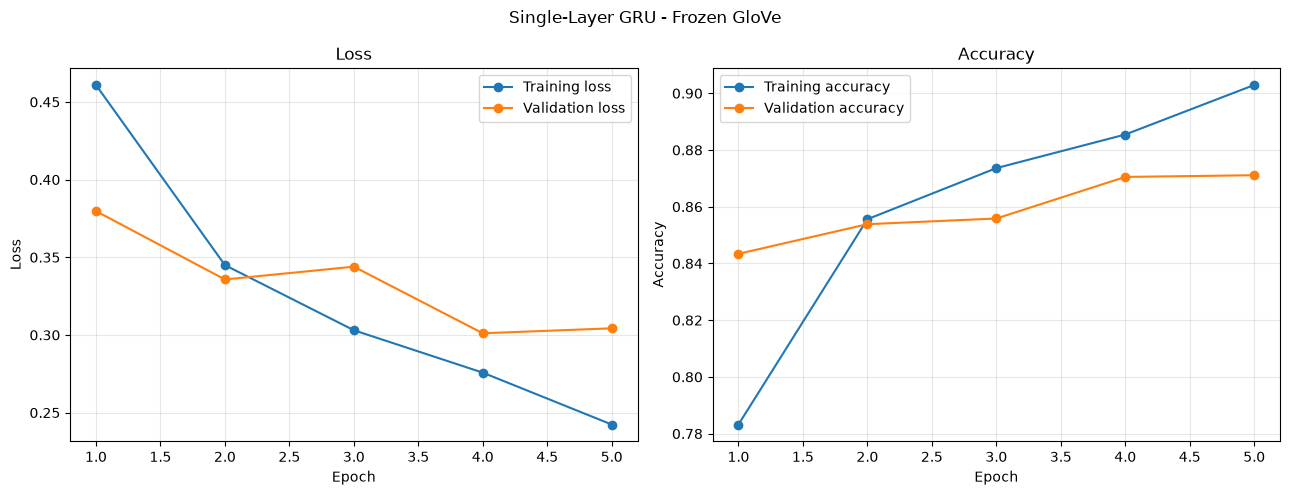

Confusion matrix saved to: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels\figures\gru_glove_frozen_confusion.png


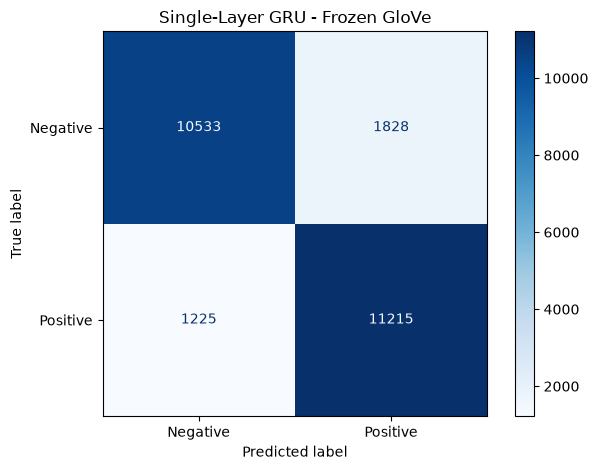

In [89]:
plot_training_history(
    history=glove_frozen_history,
    title="Single-Layer GRU - Frozen GloVe",
    file_name="gru_glove_frozen_training.png"
)

plot_confusion_matrix(
    labels=glove_frozen_labels,
    predictions=glove_frozen_predictions,
    title="Single-Layer GRU - Frozen GloVe",
    file_name="gru_glove_frozen_confusion.png"
)

In [90]:
gru_results.append({
    "Model": "GRU",
    "Embedding": "GloVe",
    "Variant": "Frozen",
    "Layers": 1,
    "Hidden Size": HIDDEN_SIZE,
    "Learning Rate": LEARNING_RATE,
    "Batch Size": BATCH_SIZE,
    "Dropout": DROPOUT,
    "Best Epoch": glove_frozen_history["best_epoch"],
    "Training Minutes": glove_frozen_history["training_minutes"],
    **glove_frozen_metrics
})

gru_experiment_data[
    ("GloVe", "Frozen", 1)
] = {
    "history": glove_frozen_history,
    "labels": glove_frozen_labels,
    "predictions": glove_frozen_predictions,
    "probabilities": glove_frozen_probabilities,
    "checkpoint": (
        MODELS_DIR /
        "gru_glove_frozen_1layer.pt"
    )
}

pd.DataFrame(gru_results)

,Model,Embedding,Variant,Layers,Hidden Size,Learning Rate,Batch Size,Dropout,Best Epoch,Training Minutes,accuracy,precision,recall,f1
0,GRU,GloVe,Frozen,1,128,0.001,32,0.3,4,37.487268,0.8769,0.859848,0.901527,0.880195


In [91]:
del glove_frozen_model
del optimizer
gc.collect()

print("Frozen GloVe model removed from memory.")

Frozen GloVe model removed from memory.


## Experiment 2: Fine-Tuned GloVe, Single-Layer GRU

In [92]:
reset_random_seeds()

experiment_train_loader = create_training_loader()

glove_finetuned_model = GRUClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    glove_finetuned_model.parameters(),
    lr=LEARNING_RATE
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in glove_finetuned_model.parameters()
    if parameter.requires_grad
)

print(glove_finetuned_model)
print(f"Trainable parameters: {trainable_parameters:,}")
print("Device:", device)

GRUClassifier(
  (embedding): Embedding(60725, 100, padding_idx=0)
  (gru): GRU(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 6,160,949
Device: cpu


In [93]:
print(
    "Training single-layer GRU "
    "with fine-tuned GloVe embeddings..."
)

glove_finetuned_history = train_model(
    model=glove_finetuned_model,
    train_loader=experiment_train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=(
        MODELS_DIR /
        "gru_glove_finetuned_1layer.pt"
    )
)

Training single-layer GRU with fine-tuned GloVe embeddings...
Epoch 01/5 | Train Loss: 0.4035 | Train Accuracy: 0.8148 | Val Loss: 0.3513 | Val Accuracy: 0.8504
Best model saved.
Epoch 02/5 | Train Loss: 0.1977 | Train Accuracy: 0.9269 | Val Loss: 0.2924 | Val Accuracy: 0.8942
Best model saved.
Epoch 03/5 | Train Loss: 0.0791 | Train Accuracy: 0.9749 | Val Loss: 0.3588 | Val Accuracy: 0.8902
Epoch 04/5 | Train Loss: 0.0233 | Train Accuracy: 0.9936 | Val Loss: 0.4170 | Val Accuracy: 0.8818
Epoch 05/5 | Train Loss: 0.0072 | Train Accuracy: 0.9984 | Val Loss: 0.5805 | Val Accuracy: 0.8713

Training completed in 40.98 minutes.
Best validation loss occurred at epoch 2.


In [94]:
(
    glove_finetuned_metrics,
    glove_finetuned_labels,
    glove_finetuned_predictions,
    glove_finetuned_probabilities
) = evaluate_model(
    model=glove_finetuned_model,
    data_loader=test_loader,
    device=device
)

print_evaluation_report(
    metrics=glove_finetuned_metrics,
    labels=glove_finetuned_labels,
    predictions=glove_finetuned_predictions
)

Metrics:
Accuracy: 0.8729
Precision: 0.9238
Recall: 0.8137
F1: 0.8652

Classification report:
              precision    recall  f1-score   support

    Negative       0.83      0.93      0.88     12361
    Positive       0.92      0.81      0.87     12440

    accuracy                           0.87     24801
   macro avg       0.88      0.87      0.87     24801
weighted avg       0.88      0.87      0.87     24801

Confusion matrix:
[[11526   835]
 [ 2318 10122]]


Training figure saved to: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels\figures\gru_glove_finetuned_training.png


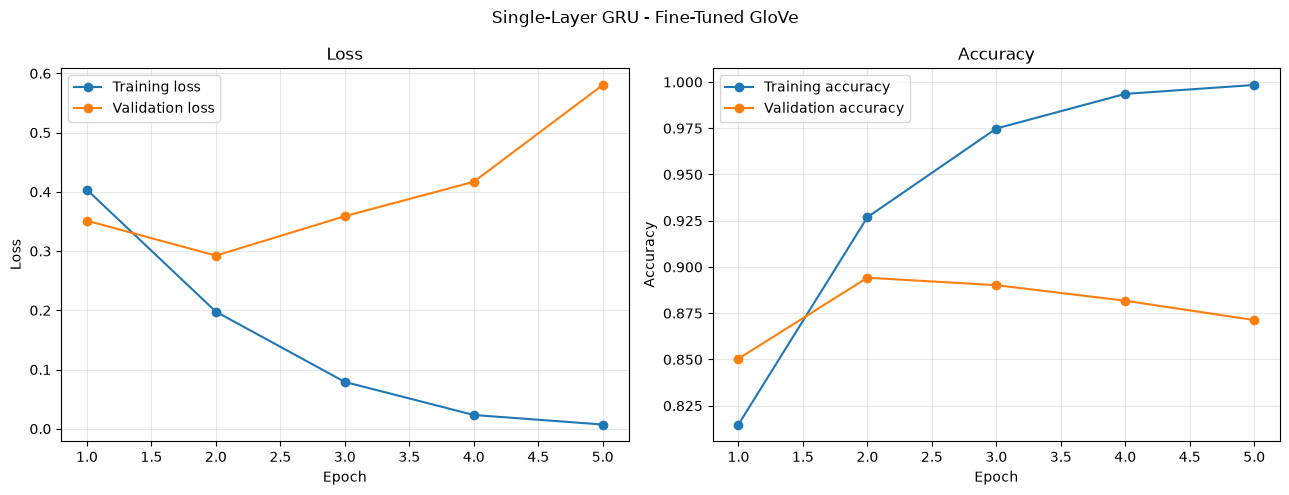

Confusion matrix saved to: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels\figures\gru_glove_finetuned_confusion.png


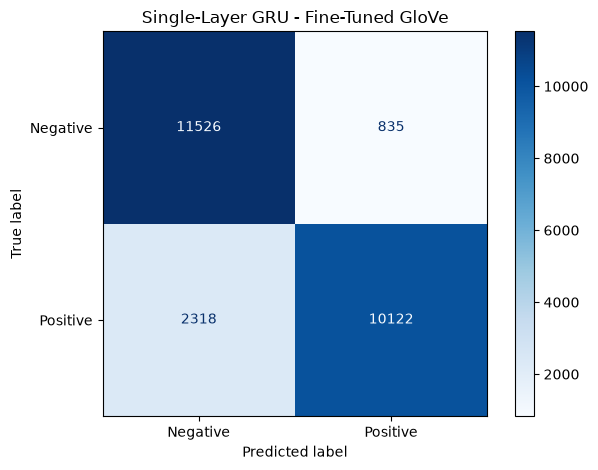

In [95]:
plot_training_history(
    history=glove_finetuned_history,
    title="Single-Layer GRU - Fine-Tuned GloVe",
    file_name="gru_glove_finetuned_training.png"
)

plot_confusion_matrix(
    labels=glove_finetuned_labels,
    predictions=glove_finetuned_predictions,
    title="Single-Layer GRU - Fine-Tuned GloVe",
    file_name="gru_glove_finetuned_confusion.png"
)

In [96]:
gru_results.append({
    "Model": "GRU",
    "Embedding": "GloVe",
    "Variant": "Fine-Tuned",
    "Layers": 1,
    "Hidden Size": HIDDEN_SIZE,
    "Learning Rate": LEARNING_RATE,
    "Batch Size": BATCH_SIZE,
    "Dropout": DROPOUT,
    "Best Epoch": glove_finetuned_history["best_epoch"],
    "Training Minutes": glove_finetuned_history["training_minutes"],
    **glove_finetuned_metrics
})

gru_experiment_data[
    ("GloVe", "Fine-Tuned", 1)
] = {
    "history": glove_finetuned_history,
    "labels": glove_finetuned_labels,
    "predictions": glove_finetuned_predictions,
    "probabilities": glove_finetuned_probabilities,
    "checkpoint": (
        MODELS_DIR /
        "gru_glove_finetuned_1layer.pt"
    )
}

pd.DataFrame(gru_results)

,Model,Embedding,Variant,Layers,Hidden Size,Learning Rate,Batch Size,Dropout,Best Epoch,Training Minutes,accuracy,precision,recall,f1
0,GRU,GloVe,Frozen,1,128,0.001,32,0.3,4,37.487268,0.876900,0.859848,0.901527,0.880195
1,GRU,GloVe,Fine-Tuned,1,128,0.001,32,0.3,2,40.980796,0.872868,0.923793,0.813666,0.865239


In [97]:
del glove_finetuned_model
del optimizer
gc.collect()

print("Fine-tuned GloVe model removed from memory.")

Fine-tuned GloVe model removed from memory.


## Experiment 3: Frozen Word2Vec, Single-Layer GRU

In [98]:
reset_random_seeds()

experiment_train_loader = create_training_loader()

word2vec_frozen_model = GRUClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        word2vec_frozen_model.parameters()
    ),
    lr=LEARNING_RATE
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in word2vec_frozen_model.parameters()
    if parameter.requires_grad
)

print(word2vec_frozen_model)
print(f"Trainable parameters: {trainable_parameters:,}")
print("Device:", device)

GRUClassifier(
  (embedding): Embedding(60725, 100, padding_idx=0)
  (gru): GRU(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 88,449
Device: cpu


In [99]:
print(
    "Training single-layer GRU "
    "with frozen Word2Vec embeddings..."
)

word2vec_frozen_history = train_model(
    model=word2vec_frozen_model,
    train_loader=experiment_train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=(
        MODELS_DIR /
        "gru_word2vec_frozen_1layer.pt"
    )
)

Training single-layer GRU with frozen Word2Vec embeddings...
Epoch 01/5 | Train Loss: 0.3797 | Train Accuracy: 0.8359 | Val Loss: 0.3519 | Val Accuracy: 0.8456
Best model saved.
Epoch 02/5 | Train Loss: 0.2857 | Train Accuracy: 0.8824 | Val Loss: 0.2872 | Val Accuracy: 0.8824
Best model saved.
Epoch 03/5 | Train Loss: 0.2606 | Train Accuracy: 0.8953 | Val Loss: 0.2915 | Val Accuracy: 0.8769
Epoch 04/5 | Train Loss: 0.2494 | Train Accuracy: 0.8983 | Val Loss: 0.2589 | Val Accuracy: 0.8948
Best model saved.
Epoch 05/5 | Train Loss: 0.2329 | Train Accuracy: 0.9035 | Val Loss: 0.2715 | Val Accuracy: 0.8888

Training completed in 37.83 minutes.
Best validation loss occurred at epoch 4.


In [100]:
(
    word2vec_frozen_metrics,
    word2vec_frozen_labels,
    word2vec_frozen_predictions,
    word2vec_frozen_probabilities
) = evaluate_model(
    model=word2vec_frozen_model,
    data_loader=test_loader,
    device=device
)

print_evaluation_report(
    metrics=word2vec_frozen_metrics,
    labels=word2vec_frozen_labels,
    predictions=word2vec_frozen_predictions
)

Metrics:
Accuracy: 0.8940
Precision: 0.8852
Recall: 0.9062
F1: 0.8956

Classification report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89     12361
    Positive       0.89      0.91      0.90     12440

    accuracy                           0.89     24801
   macro avg       0.89      0.89      0.89     24801
weighted avg       0.89      0.89      0.89     24801

Confusion matrix:
[[10899  1462]
 [ 1167 11273]]


Training figure saved to: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels\figures\gru_word2vec_frozen_training.png


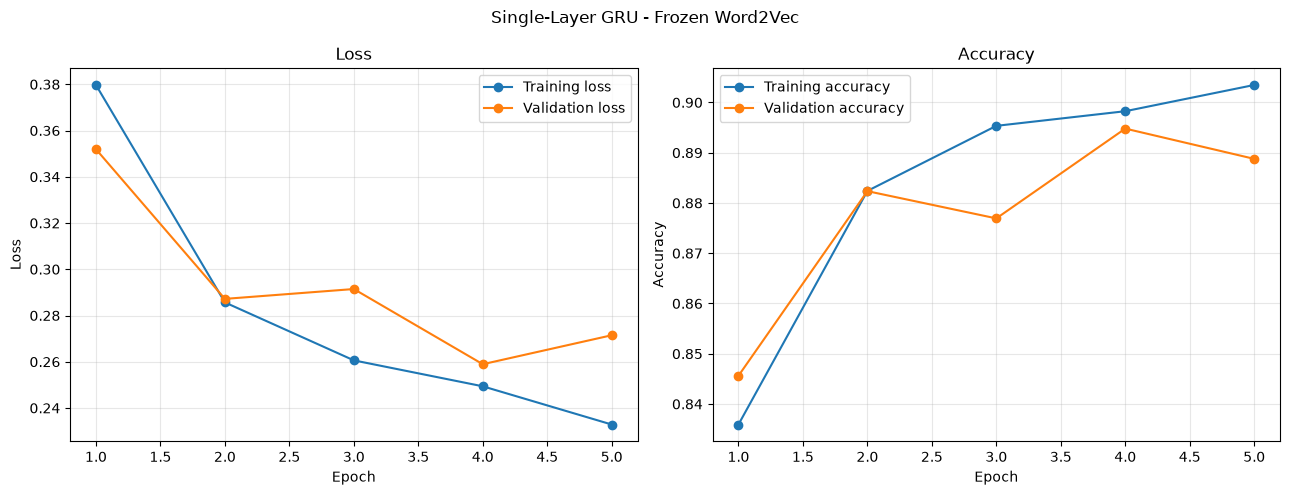

Confusion matrix saved to: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels\figures\gru_word2vec_frozen_confusion.png


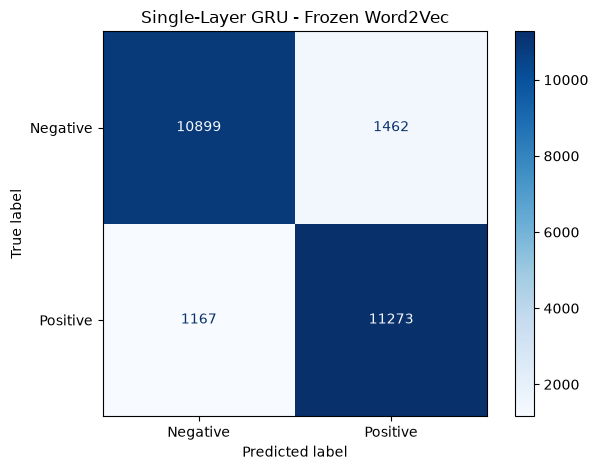

In [101]:
plot_training_history(
    history=word2vec_frozen_history,
    title="Single-Layer GRU - Frozen Word2Vec",
    file_name="gru_word2vec_frozen_training.png"
)

plot_confusion_matrix(
    labels=word2vec_frozen_labels,
    predictions=word2vec_frozen_predictions,
    title="Single-Layer GRU - Frozen Word2Vec",
    file_name="gru_word2vec_frozen_confusion.png"
)

In [102]:
gru_results.append({
    "Model": "GRU",
    "Embedding": "Word2Vec",
    "Variant": "Frozen",
    "Layers": 1,
    "Hidden Size": HIDDEN_SIZE,
    "Learning Rate": LEARNING_RATE,
    "Batch Size": BATCH_SIZE,
    "Dropout": DROPOUT,
    "Best Epoch": word2vec_frozen_history["best_epoch"],
    "Training Minutes": word2vec_frozen_history["training_minutes"],
    **word2vec_frozen_metrics
})

gru_experiment_data[
    ("Word2Vec", "Frozen", 1)
] = {
    "history": word2vec_frozen_history,
    "labels": word2vec_frozen_labels,
    "predictions": word2vec_frozen_predictions,
    "probabilities": word2vec_frozen_probabilities,
    "checkpoint": (
        MODELS_DIR /
        "gru_word2vec_frozen_1layer.pt"
    )
}

results_preview = pd.DataFrame(gru_results)

results_preview[
    [
        "Embedding",
        "Variant",
        "Layers",
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
]

,Embedding,Variant,Layers,accuracy,precision,recall,f1
0,GloVe,Frozen,1,0.876900,0.859848,0.901527,0.880195
1,GloVe,Fine-Tuned,1,0.872868,0.923793,0.813666,0.865239
2,Word2Vec,Frozen,1,0.893996,0.885198,0.906190,0.895571


,Embedding,Variant,Layers,accuracy,precision,recall,f1
0,GloVe,Frozen,1,0.876900,0.859848,0.901527,0.880195
1,GloVe,Fine-Tuned,1,0.872868,0.923793,0.813666,0.865239
2,Word2Vec,Frozen,1,0.893996,0.885198,0.906190,0.895571
3,Word2Vec,Frozen,1,0.893996,0.885198,0.906190,0.895571


In [104]:
del word2vec_frozen_model
del optimizer
gc.collect()

print("Frozen Word2Vec model removed from memory.")

Frozen Word2Vec model removed from memory.


## Experiment 4: Fine-Tuned Word2Vec, Single-Layer GRU

In [105]:
reset_random_seeds()

experiment_train_loader = create_training_loader()

word2vec_finetuned_model = GRUClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    word2vec_finetuned_model.parameters(),
    lr=LEARNING_RATE
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in word2vec_finetuned_model.parameters()
    if parameter.requires_grad
)

print(word2vec_finetuned_model)
print(f"Trainable parameters: {trainable_parameters:,}")
print("Device:", device)

GRUClassifier(
  (embedding): Embedding(60725, 100, padding_idx=0)
  (gru): GRU(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 6,160,949
Device: cpu


In [106]:
print(
    "Training single-layer GRU "
    "with fine-tuned Word2Vec embeddings..."
)

word2vec_finetuned_history = train_model(
    model=word2vec_finetuned_model,
    train_loader=experiment_train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=(
        MODELS_DIR /
        "gru_word2vec_finetuned_1layer.pt"
    )
)

Training single-layer GRU with fine-tuned Word2Vec embeddings...
Epoch 01/5 | Train Loss: 0.3535 | Train Accuracy: 0.8508 | Val Loss: 0.3222 | Val Accuracy: 0.8603
Best model saved.
Epoch 02/5 | Train Loss: 0.1827 | Train Accuracy: 0.9334 | Val Loss: 0.2865 | Val Accuracy: 0.8946
Best model saved.
Epoch 03/5 | Train Loss: 0.0766 | Train Accuracy: 0.9763 | Val Loss: 0.3551 | Val Accuracy: 0.8822
Epoch 04/5 | Train Loss: 0.0223 | Train Accuracy: 0.9933 | Val Loss: 0.3914 | Val Accuracy: 0.8783
Epoch 05/5 | Train Loss: 0.0088 | Train Accuracy: 0.9973 | Val Loss: 0.5177 | Val Accuracy: 0.8803

Training completed in 41.98 minutes.
Best validation loss occurred at epoch 2.


In [107]:
(
    word2vec_finetuned_metrics,
    word2vec_finetuned_labels,
    word2vec_finetuned_predictions,
    word2vec_finetuned_probabilities
) = evaluate_model(
    model=word2vec_finetuned_model,
    data_loader=test_loader,
    device=device
)

print_evaluation_report(
    metrics=word2vec_finetuned_metrics,
    labels=word2vec_finetuned_labels,
    predictions=word2vec_finetuned_predictions
)

Metrics:
Accuracy: 0.8616
Precision: 0.9397
Recall: 0.7737
F1: 0.8487

Classification report:
              precision    recall  f1-score   support

    Negative       0.81      0.95      0.87     12361
    Positive       0.94      0.77      0.85     12440

    accuracy                           0.86     24801
   macro avg       0.87      0.86      0.86     24801
weighted avg       0.87      0.86      0.86     24801

Confusion matrix:
[[11743   618]
 [ 2815  9625]]


Training figure saved to: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels\figures\gru_word2vec_finetuned_training.png


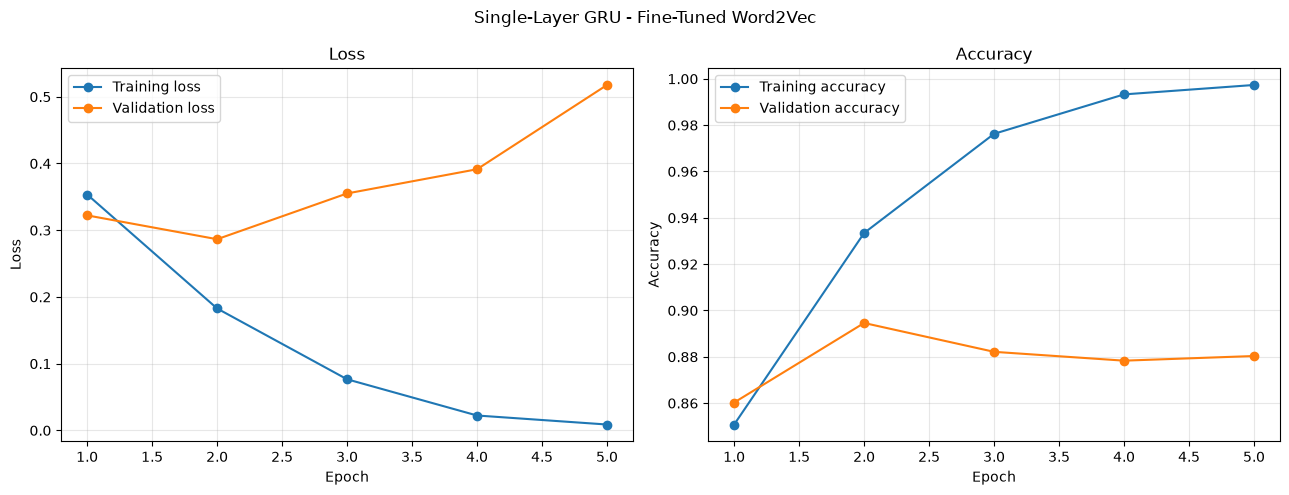

Confusion matrix saved to: C:\Users\Admin\Downloads\Assignment4_NLP_SequenceModels\figures\gru_word2vec_finetuned_confusion.png


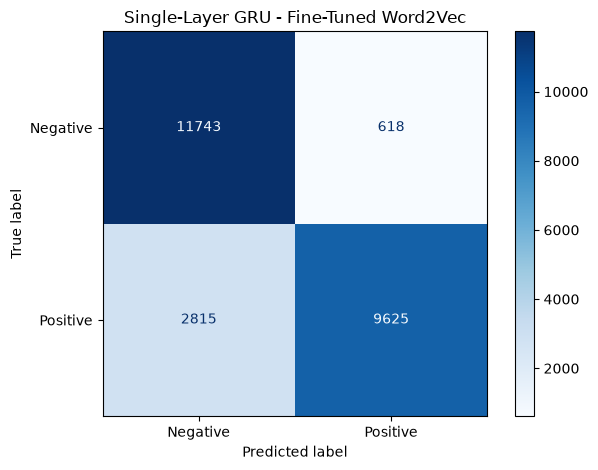

In [108]:
plot_training_history(
    history=word2vec_finetuned_history,
    title="Single-Layer GRU - Fine-Tuned Word2Vec",
    file_name="gru_word2vec_finetuned_training.png"
)

plot_confusion_matrix(
    labels=word2vec_finetuned_labels,
    predictions=word2vec_finetuned_predictions,
    title="Single-Layer GRU - Fine-Tuned Word2Vec",
    file_name="gru_word2vec_finetuned_confusion.png"
)

In [109]:
gru_results.append({
    "Model": "GRU",
    "Embedding": "Word2Vec",
    "Variant": "Fine-Tuned",
    "Layers": 1,
    "Hidden Size": HIDDEN_SIZE,
    "Learning Rate": LEARNING_RATE,
    "Batch Size": BATCH_SIZE,
    "Dropout": DROPOUT,
    "Best Epoch": word2vec_finetuned_history["best_epoch"],
    "Training Minutes": word2vec_finetuned_history["training_minutes"],
    **word2vec_finetuned_metrics
})

gru_experiment_data[
    ("Word2Vec", "Fine-Tuned", 1)
] = {
    "history": word2vec_finetuned_history,
    "labels": word2vec_finetuned_labels,
    "predictions": word2vec_finetuned_predictions,
    "probabilities": word2vec_finetuned_probabilities,
    "checkpoint": (
        MODELS_DIR /
        "gru_word2vec_finetuned_1layer.pt"
    )
}

single_layer_results = pd.DataFrame(
    gru_results
).sort_values(
    by="f1",
    ascending=False
).reset_index(drop=True)

single_layer_results[
    [
        "Embedding",
        "Variant",
        "Layers",
        "Best Epoch",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "Training Minutes"
    ]
]

,Embedding,Variant,Layers,Best Epoch,accuracy,precision,recall,f1,Training Minutes
0,Word2Vec,Frozen,1,4,0.893996,0.885198,0.906190,0.895571,37.825528
1,Word2Vec,Frozen,1,4,0.893996,0.885198,0.906190,0.895571,37.825528
2,GloVe,Frozen,1,4,0.876900,0.859848,0.901527,0.880195,37.487268
3,GloVe,Fine-Tuned,1,2,0.872868,0.923793,0.813666,0.865239,40.980796
4,Word2Vec,Fine-Tuned,1,2,0.861578,0.939666,0.773714,0.848653,41.979988


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_df = pd.DataFrame([
    {
        "Configuration": "Word2Vec Frozen",
        "Embedding": "Word2Vec",
        "Variant": "Frozen",
        "accuracy": 0.893996,
        "precision": 0.885198,
        "recall": 0.906190,
        "f1": 0.895571,
        "Best Epoch": 4,
        "Training Minutes": 37.825528
    },
    {
        "Configuration": "GloVe Frozen",
        "Embedding": "GloVe",
        "Variant": "Frozen",
        "accuracy": 0.876900,
        "precision": 0.859848,
        "recall": 0.901527,
        "f1": 0.880195,
        "Best Epoch": 4,
        "Training Minutes": 37.487268
    },
    {
        "Configuration": "GloVe Fine-Tuned",
        "Embedding": "GloVe",
        "Variant": "Fine-Tuned",
        "accuracy": 0.872868,
        "precision": 0.923793,
        "recall": 0.813666,
        "f1": 0.865239,
        "Best Epoch": 2,
        "Training Minutes": 40.980796
    },
    {
        "Configuration": "Word2Vec Fine-Tuned",
        "Embedding": "Word2Vec",
        "Variant": "Fine-Tuned",
        "accuracy": 0.861578,
        "precision": 0.939666,
        "recall": 0.773714,
        "f1": 0.848653,
        "Best Epoch": 2,
        "Training Minutes": 41.979988
    }
])

results_df = results_df.sort_values(
    "f1",
    ascending=False
).reset_index(drop=True)

results_df

,Configuration,Embedding,Variant,accuracy,precision,recall,f1,Best Epoch,Training Minutes
0,Word2Vec Frozen,Word2Vec,Frozen,0.893996,0.885198,0.906190,0.895571,4,37.825528
1,GloVe Frozen,GloVe,Frozen,0.876900,0.859848,0.901527,0.880195,4,37.487268
2,GloVe Fine-Tuned,GloVe,Fine-Tuned,0.872868,0.923793,0.813666,0.865239,2,40.980796
3,Word2Vec Fine-Tuned,Word2Vec,Fine-Tuned,0.861578,0.939666,0.773714,0.848653,2,41.979988


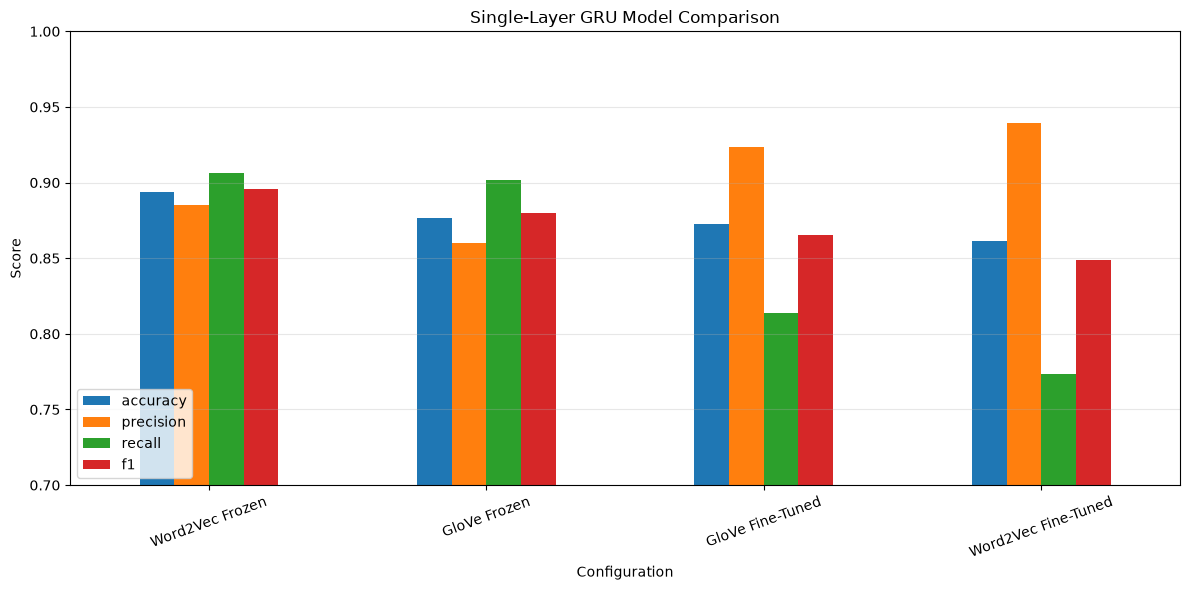

In [9]:
comparison_df = results_df.set_index(
    "Configuration"
)[
    ["accuracy", "precision", "recall", "f1"]
]

comparison_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Single-Layer GRU Model Comparison")
plt.ylabel("Score")
plt.xlabel("Configuration")
plt.ylim(0.70, 1.0)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [42]:
best_result = results_df.sort_values(
    by="f1",
    ascending=False
).iloc[0]

print("Best model:")
print(best_result)

Best model:
Configuration       Word2Vec Frozen
Embedding                  Word2Vec
Variant                      Frozen
accuracy                   0.893996
precision                  0.885198
recall                      0.90619
f1                         0.895571
Best Epoch                        4
Training Minutes          37.825528
Name: 0, dtype: object


In [44]:
(
    best_metrics,
    best_labels,
    best_predictions,
    best_probabilities
) = evaluate_model(
    model=best_model,
    data_loader=test_loader,
    device=device
)

print_evaluation_report(
    metrics=best_metrics,
    labels=best_labels,
    predictions=best_predictions
)

Metrics:
Accuracy: 0.8940
Precision: 0.8852
Recall: 0.9062
F1: 0.8956

Classification report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89     12361
    Positive       0.89      0.91      0.90     12440

    accuracy                           0.89     24801
   macro avg       0.89      0.89      0.89     24801
weighted avg       0.89      0.89      0.89     24801

Confusion matrix:
[[10899  1462]
 [ 1167 11273]]


# Error Analysis

In [48]:
full_test_lengths = (
    test_dataset.lengths
    .cpu()
    .numpy()
    .reshape(-1)
)

print("Full test lengths:", full_test_lengths.shape)

Full test lengths: (24801,)


In [49]:
test_df = pd.read_csv(
    DATA_DIR / "test_processed.csv"
)

print("Best GRU variant: Word2Vec (Frozen)")
print(f"F1: {best_metrics['f1']:.4f}")


def analyze_errors(
    labels,
    predictions,
    probabilities,
    texts,
    lengths,
    n_examples=5
):
    labels = np.asarray(
        labels
    ).reshape(-1)

    predictions = np.asarray(
        predictions
    ).reshape(-1)

    probabilities = np.asarray(
        probabilities
    ).reshape(-1)

    lengths = np.asarray(
        lengths
    ).reshape(-1)

    texts = texts.reset_index(
        drop=True
    )

    misclassified_mask = (
        predictions != labels
    )

    false_positive_mask = (
        misclassified_mask
        & (predictions == 1)
    )

    false_negative_mask = (
        misclassified_mask
        & (predictions == 0)
    )

    print(f"Total test samples: {len(labels)}")

    print(
        f"Misclassified: "
        f"{misclassified_mask.sum()} "
        f"({misclassified_mask.mean() * 100:.2f}%)"
    )

    print(
        "False positives "
        "(predicted positive, actually negative):",
        false_positive_mask.sum()
    )

    print(
        "False negatives "
        "(predicted negative, actually positive):",
        false_negative_mask.sum()
    )

    print("\n--- Sample False Positives ---")

    for index in np.where(
        false_positive_mask
    )[0][:n_examples]:

        print(
            f"[length={lengths[index]}, "
            f"confidence={probabilities[index]:.3f}] "
            f"{texts[index][:200]}"
        )

        print()

    print("--- Sample False Negatives ---")

    for index in np.where(
        false_negative_mask
    )[0][:n_examples]:

        print(
            f"[length={lengths[index]}, "
            f"confidence={probabilities[index]:.3f}] "
            f"{texts[index][:200]}"
        )

        print()

    length_bins = pd.qcut(
        lengths,
        q=4,
        duplicates="drop"
    )

    error_by_length = pd.DataFrame({
        "length_bin": length_bins,
        "is_error": misclassified_mask
    }).groupby(
        "length_bin",
        observed=True
    )["is_error"].mean()

    print(
        "--- Error rate by review "
        "length quartile ---"
    )

    print(error_by_length)

    plt.figure(figsize=(8, 5))

    error_by_length.plot(
        kind="bar"
    )

    plt.ylabel("Error Rate")

    plt.title(
        "GRU Error Rate by Review "
        "Length Quartile"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()
    plt.show()

    return (
        misclassified_mask,
        false_positive_mask,
        false_negative_mask
    )

Best GRU variant: Word2Vec (Frozen)
F1: 0.8956


Total test samples: 24801
Misclassified: 2629 (10.60%)
False positives (predicted positive, actually negative): 1462
False negatives (predicted negative, actually positive): 1167

--- Sample False Positives ---
[length=142, confidence=0.887] brass picture movie not fitting word really somewhat brassy alluring visual quality reminiscent expensive high class tv commercial unfortunately brass picture feature film pretense wanting entertain v

[length=145, confidence=0.525] first would like say fan actor appear film time rented wanted like think main reason disappointed outside box promised suspense thriller eye suspense thriller british movie like something ruth rendell

[length=117, confidence=0.898] earth destroyed nuclear holocaust well part earth somewhere italy band purebred survivor without radioactive contamination holed massive mansion surrounded lush ground waiting next opportunity go hunt

[length=48, confidence=0.692] new york family last neighborhood get television set nearly 

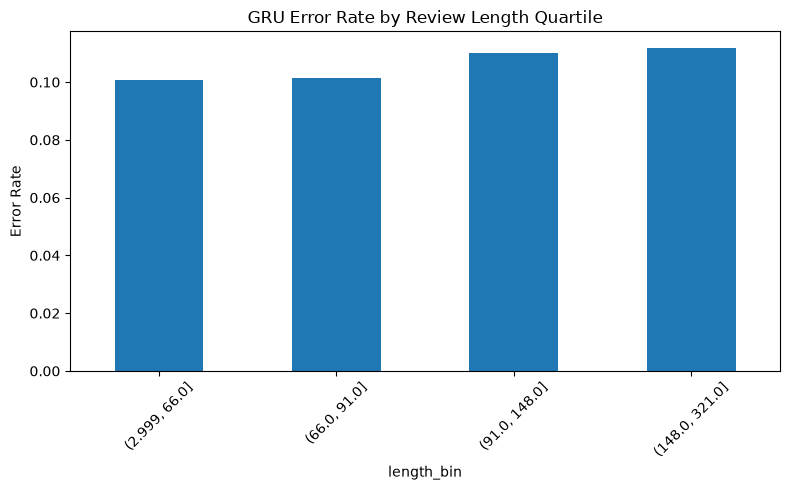

In [50]:
(
    misclassified_mask,
    false_positive_mask,
    false_negative_mask
) = analyze_errors(
    labels=best_labels,
    predictions=best_predictions,
    probabilities=best_probabilities,
    texts=test_df["processed_text"],
    lengths=full_test_lengths
)